# Netflix EDA

## Aryan Pathania (Ar3missss)

### Dataset available at: *https://www.kaggle.com/datasets/shivamb/netflix-shows*


## Objectives

- What type of content dominates (Movies vs TV Shows)?
- How has Netflix content grown over time?
- In which months is content most and least frequently added?
- Which countries produce the most content on Netflix?
- What are the most common genres on Netflix?
- What type of audience does Netflix target based on content ratings?
- What is the distribution of content ratings (e.g., TV-MA, PG-13)?
- What is the average duration of movies?
- Which genres are popular in specific countries?

# Import Libraries

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [50]:
file_path = os.path.join("data","netflix_titles.csv")
df = pd.read_csv(file_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Data Overview

- Dataset contains 8807 rows and 12 columns
- Most columns are type object (categorical / text data) 
- Only release_year is numerical
- Missing Values are present in columns like (director, cast, country, date_added, rating, duration)
- 'date_added' is stored as an object and needs to be converted to datetime format for time-based analysis
- There are no Duplicates values

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.shape

(8807, 12)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [54]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

# Data cleaning and Preprocessing

### Missing Values

In [55]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

- Missing Values are present in following columns -- director, country, cast, date_added, rating, duration
- 'director' has a high number of missing values (~30%) while others are moderate


### Handling missing values

In [56]:
df.fillna({
    'director' : 'Unknown',
    'country' : 'Unknown',
    'cast' : 'Unknown',
    'rating' : 'Not Rated',
    'duration' : 'Unknown'
}, inplace= True)
df=df[df['date_added'].notna()]
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

- Missing values in `director`, `country`, `cast`, and `duration` were handled by replacing them with `Unknown`.
- Missing values in `rating` were replaced with `Not Rated`.
- Only 10 rows were missing `date_added`, so those rows were dropped to keep the time-based analysis reliable.

In [57]:
country_split = df['country'].str.split(',').explode().str.strip()
country_split.head()

0    United States
1     South Africa
2          Unknown
3          Unknown
4            India
Name: country, dtype: str

- Some titles list multiple countries in one row, so `str.split(',').explode().str.strip()` is used when we need country-level counts.

### Date Conversion

In [58]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format="%B %d, %Y")
df['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

- The 'date_added' column is converted into date-time format for time-based analysis

# Feature Extraction

In [59]:
day_order=['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
df['day_added'] = df['date_added'].dt.day_name()
df['day_added']=pd.Categorical(df['day_added'],categories=day_order,ordered=True)

df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year
df[['date_added', 'day_added' , 'month_added', 'year_added']].head()

,date_added,day_added,month_added,year_added
0,2021-09-25,Saturday,9,2021
1,2021-09-24,Friday,9,2021
2,2021-09-24,Friday,9,2021
3,2021-09-24,Friday,9,2021
4,2021-09-24,Friday,9,2021


- Day, month, and year were extracted separately from `date_added`.

### Movie Duration

In [60]:
df['movie_duration'] = df['duration'].where(df['type'] == 'Movie').str.extract(r'(\d+)').astype(float)
df['seasons'] = df['duration'].where(df['type'] == 'TV Show').str.extract(r'(\d+)').astype(float)
df[['type','duration','movie_duration','seasons']].head()

,type,duration,movie_duration,seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0


- Movie durations and TV show seasons were extracted into separate numeric columns.

# Exploratory Data Analysis

## Q1 -- Are movies more common than TV shows?

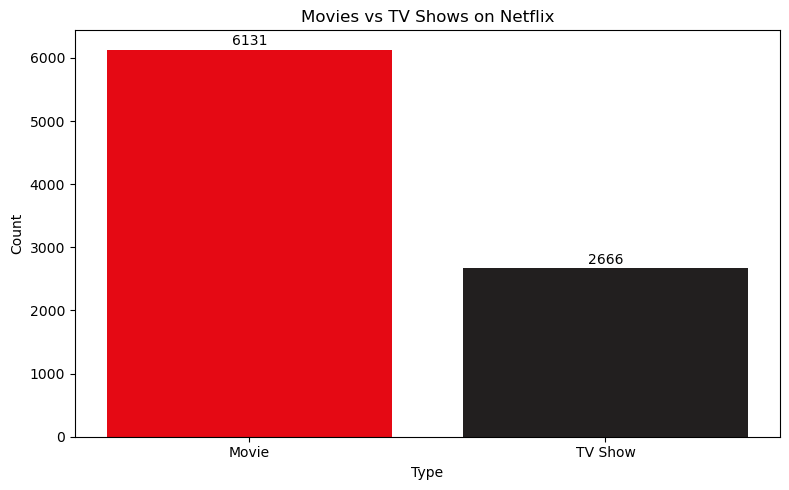

In [61]:
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(type_counts['type'], type_counts['count'], color=['#E50914', '#221F1F'])
ax.set_title('Movies vs TV Shows on Netflix')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.bar_label(bars, fmt='%d', padding=1)

plt.tight_layout()
plt.savefig('outputs/netflix/Movies vs Tv Shows.png',dpi=300)
plt.show() 

- Movies are more common on Netflix, with 6,131 titles compared with 2,666 TV Shows.

# Q2 -- Which countries produce the most content on Netflix?

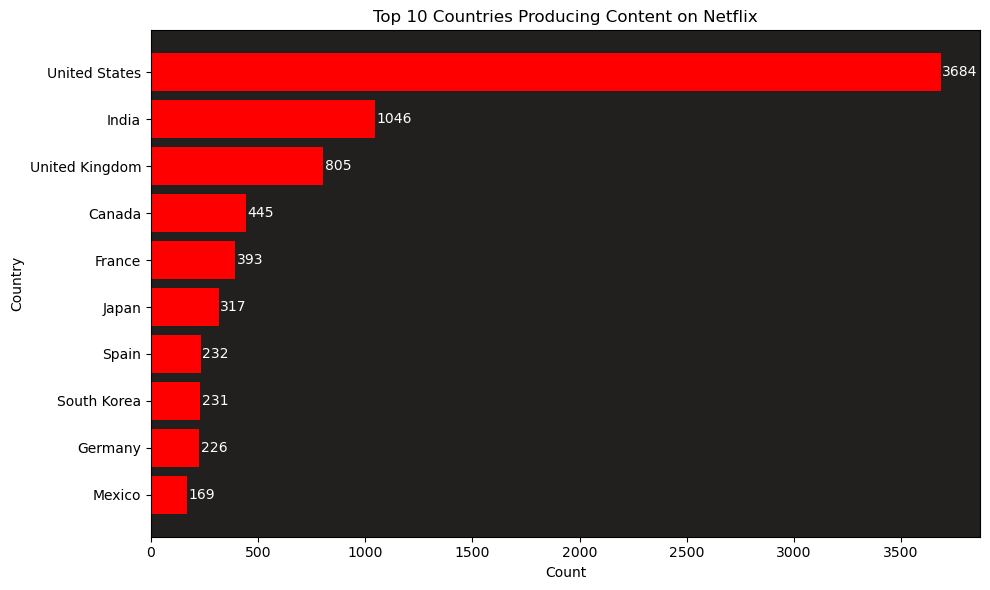

In [62]:
country_counts = (
    df[df['country'] != 'Unknown']['country']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)
country_counts.columns = ['country', 'count']
top_10_countries = country_counts.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_10_countries['country'], top_10_countries['count'], color = 'red')
ax.set_title('Top 10 Countries Producing Content on Netflix')
ax.set_xlabel('Count')
ax.set_ylabel('Country')
ax.set_facecolor('#221F1F')
ax.bar_label(bars , fmt='%d', padding=1 , color = 'white')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/netflix/Top 10 countries producing content on netflix.png',dpi=300)
plt.show()


- The United States produces the most content on Netflix, followed by India and the United Kingdom.
- `Unknown` values were excluded from the chart because they represent missing country data, not a real country.

# Q3 -- What genre are most frequent on Netflix ?

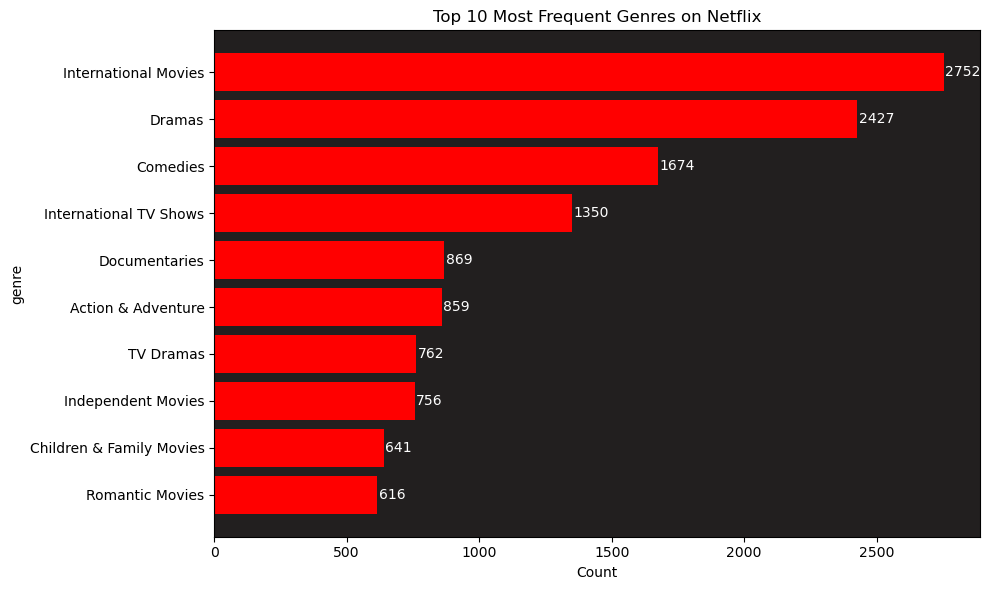

In [63]:
genre_count=(
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
    )
genre_count.columns = ['genre','count']
top_10_genre = genre_count.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_10_genre['genre'], top_10_genre['count'], color = 'red')
ax.set_title('Top 10 Most Frequent Genres on Netflix')
ax.set_xlabel('Count')
ax.set_ylabel('genre')
ax.set_facecolor('#221F1F')
ax.bar_label(bars , fmt='%d', padding=1 ,color = 'white')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/netflix/Top 10 Most Frequent Genres on Netflix.png',dpi=300)
plt.show()

- International Movies are the most frequent genre on Netflix, followed by Dramas and Comedies.

# Q4 -- How has Netflix Content grown over time ?

## Yearly

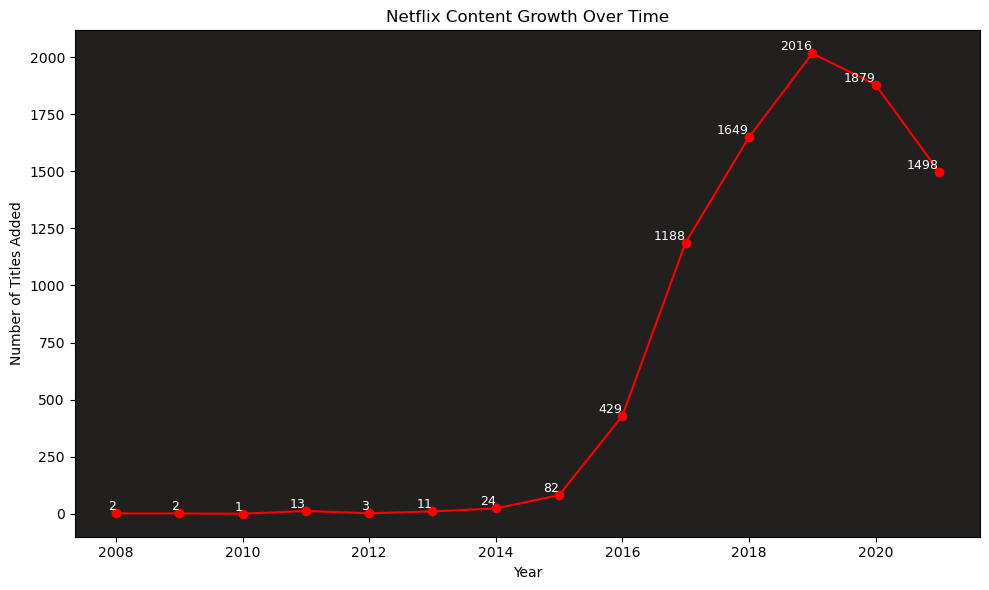

In [64]:
yearly_content = df.groupby('year_added').size().reset_index()
yearly_content.columns = ['year','count']

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(yearly_content['year'],yearly_content['count'],color='red', marker='o')
ax.set_title('Netflix Content Growth Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.set_facecolor('#221F1F')
for x, y in zip(yearly_content['year'], yearly_content['count']):
    ax.text(x, y, str(y), color='white', ha='right', va='bottom' ,fontsize= 9)
plt.tight_layout()
plt.savefig('outputs/netflix/Netflix Content growth over time.png',dpi=300)
plt.show()

- Content additions were very low before 2015, with minimal yearly releases
- From 2016 onward, there is a sharp rise, indicating aggressive expansion
- The platform peaks around 2019, showing the highest number of titles added
- After 2019, there is a slight decline, possibly due to market saturation or strategy change

## Monthly

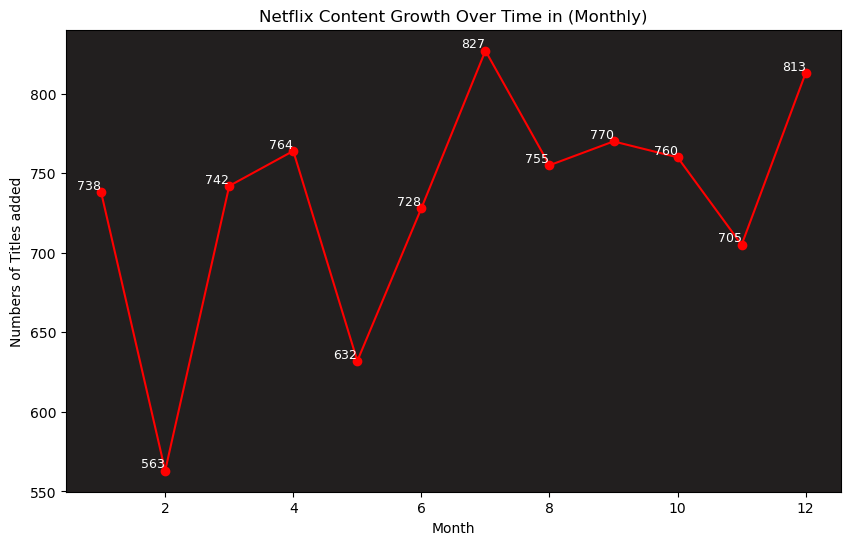

In [65]:
monthly_content = df.groupby('month_added').size().reset_index()
monthly_content.columns = ['month','count']

fix,ax = plt.subplots(figsize=(10,6))
ax.plot(monthly_content['month'],monthly_content['count'],color='red',marker='o')
ax.set_title('Netflix Content Growth Over Time in (Monthly)')
ax.set_xlabel('Month')
ax.set_ylabel('Numbers of Titles added')
ax.set_facecolor('#221F1F')
for x,y in zip(monthly_content['month'],monthly_content['count']):
    ax.text(x,y,str(y), color ='white',ha='right',va='bottom',fontsize=9)
plt.tight_layout
plt.savefig('outputs/netflix/Netflix Content Growth Over Time in (Monthly).png',dpi=300)
plt.show()


- Content additions are lowest in February, making it the weakest month for releases
- A strong increase is seen from March to July, with July being the peak month
- After July, additions remain relatively stable with minor fluctuations
- A noticeable dip occurs again in November, followed by a sharp rise in December


## Daily

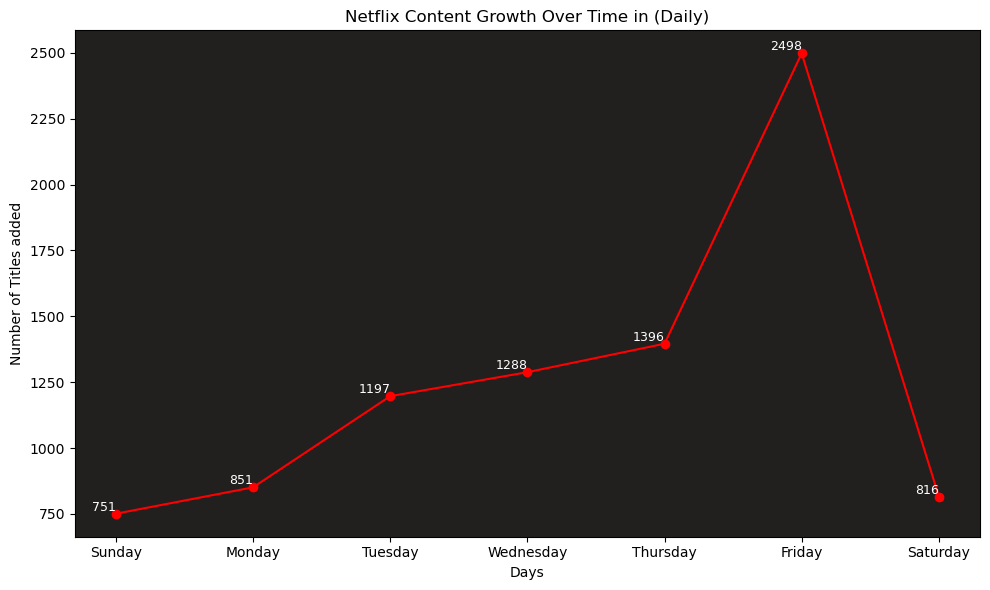

In [66]:
daily_content = df.groupby('day_added').size().reset_index()
daily_content.columns=['day','count']

fig,ax = plt.subplots(figsize=(10,6))
ax.plot(daily_content['day'],daily_content['count'],color='red',marker='o')
ax.set_title('Netflix Content Growth Over Time in (Daily)')
ax.set_xlabel('Days')
ax.set_ylabel('Number of Titles added')
ax.set_facecolor('#221f1f')
for x,y in zip(daily_content['day'],daily_content['count']):
    ax.text(x,y,str(y),color='white',ha='right',va='bottom',fontsize=9)

plt.tight_layout()
plt.savefig('outputs/netflix/Netflix Content Growth Over Time in (Daily).png',dpi=300)
plt.show()


- Content additions are lowest on Sunday and Saturday, indicating reduced weekend releases
- A steady increase is observed from Monday to Thursday, showing consistent weekday activity
- Friday has the highest number of releases, making it the peak day
- After Friday, there is a sharp drop on Saturday, suggesting minimal new content over weekends

# Q5 -- What type of audience does Netflix target based on content ratings?

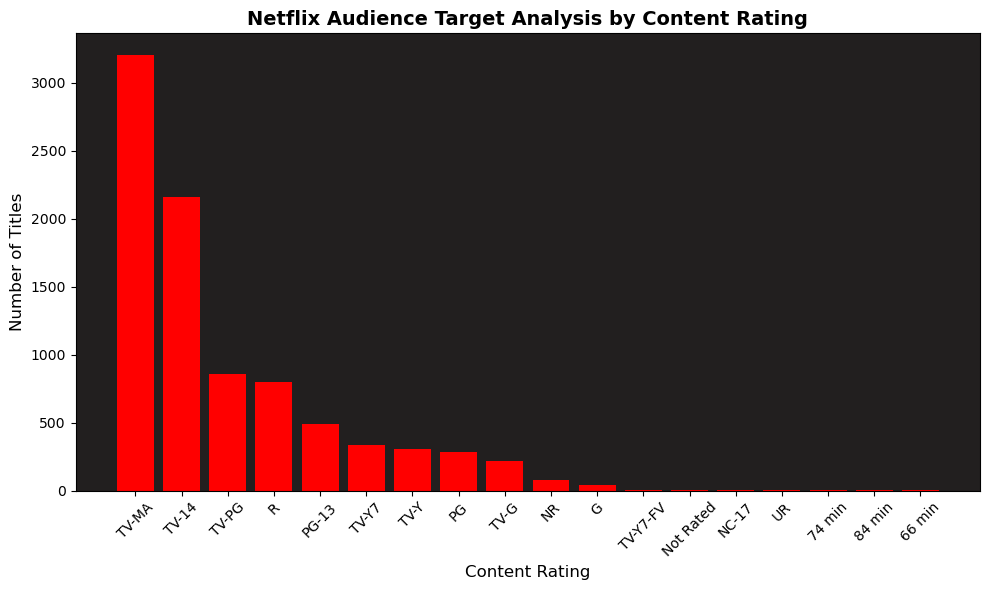

In [71]:
ratings_counts = df['rating'].value_counts().reset_index()
ratings_counts.columns = ['rating', 'count']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(ratings_counts['rating'], ratings_counts['count'], color='red')
ax.set_title('Netflix Audience Target Analysis by Content Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.set_facecolor('#221f1f')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/netflix/Audience Target Analysis.png', dpi=300)
plt.show()

- The majority of content is rated TV-MA and TV-14, clearly indicating a strong focus on adult and young adult audiences
- Moderate presence of TV-PG and R-rated content suggests some inclusion of general and slightly mature viewers
- Kids-focused ratings (TV-Y, TV-G, G) have significantly lower counts, showing limited emphasis on children’s content
- A very small portion of content falls under niche or uncommon ratings (e.g., NC-17, UR), indicating they are not a strategic focus